In [72]:
%matplotlib widget

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import warnings

from IPython.display import display
from matplotlib.ticker import AutoMinorLocator

from pyLIMA import event, telescopes
from pyLIMA.models import USBL_model
from pyLIMA.caustics import binary_caustics

from erfa import ErfaWarning


# ============================================================
# Warnings
# ============================================================

warnings.filterwarnings(
    "ignore",
    category=ErfaWarning,
)


# ============================================================
# Paths
# ============================================================

current_path = os.getcwd()
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)

sys.path.append(parent_directory)
sys.path.append("/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/")

EPHEMERIDES_PATH = (
    "/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/"
    "ephemerides/Roman_positions.npy"
)

roman_ephemerides = np.load(EPHEMERIDES_PATH).astype(float)
t0_ref = float(np.mean(roman_ephemerides[:, 0]))

print("Roman ephemerides loaded.")
print("t0_ref =", t0_ref)


# ============================================================
# Helpers
# ============================================================

def _arr(x):
    return np.asarray(getattr(x, "value", x))


def plot_binary_caustics_and_critical_curves(
    ax,
    separation,
    q_mass,
    resolution=5000,
    plot_critical_curves=True,
):
    """
    Grafica caústicas, curvas críticas y posiciones de las masas
    para una lente binaria en la convención de pyLIMA.
    """

    try:
        regime, caustics, cc = (
            binary_caustics.find_2_lenses_caustics_and_critical_curves(
                separation,
                q_mass,
                resolution=resolution,
            )
        )

    except Exception as e:
        ax.text(
            0.5,
            0.02,
            f"No pude calcular caústicas:\n{e}",
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=8,
            color="red",
        )
        return

    center_of_mass = separation * q_mass / (1.0 + q_mass)

    x1 = -center_of_mass
    x2 = -center_of_mass + separation

    ax.scatter(
        [x1],
        [0.0],
        marker="+",
        s=120,
        color="k",
        zorder=6,
        label="M1",
    )

    ax.scatter(
        [x2],
        [0.0],
        marker="+",
        s=120,
        color="gray",
        zorder=6,
        label="M2",
    )

    ax.annotate(
        "M1",
        (x1, 0.0),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
    )

    ax.annotate(
        "M2",
        (x2, 0.0),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
    )

    for count, caustic in enumerate(caustics):
        try:
            label_caustic = "Caústica" if count == 0 else None

            ax.plot(
                caustic.real,
                caustic.imag,
                lw=2.2,
                color="red",
                label=label_caustic,
                zorder=5,
            )

            if plot_critical_curves:
                label_cc = "Curva crítica" if count == 0 else None

                ax.plot(
                    cc[count].real,
                    cc[count].imag,
                    "--",
                    color="k",
                    lw=1.0,
                    alpha=0.75,
                    label=label_cc,
                    zorder=4,
                )

        except AttributeError:
            pass


def build_two_telescope_event(
    t_earth,
    t_space,
    ephemerides,
    mag_earth=19.0,
    mag_space=19.0,
    emag_earth=1e-9,
    emag_space=1e-9,
):
    """
    Construye un evento pyLIMA con dos telescopios:
    - ODI en Tierra.
    - Roman en espacio, con efemérides.
    """

    ev = event.Event()
    ev.name = "Simulated"
    ev.ra = 170.0
    ev.dec = -70.0

    # ----------------------------
    # Telescopio en Tierra
    # ----------------------------

    lightcurve_earth = np.c_[
        t_earth,
        np.full_like(t_earth, mag_earth),
        np.full_like(t_earth, emag_earth),
    ]

    tel_earth = telescopes.Telescope(
        name="ODI",
        camera_filter="G",
        lightcurve=lightcurve_earth.astype(float),
        lightcurve_names=["time", "mag", "err_mag"],
        lightcurve_units=["JD", "mag", "mag"],
        location="Earth",
    )

    ev.telescopes.append(tel_earth)

    # ----------------------------
    # Telescopio en Espacio
    # ----------------------------

    lightcurve_space = np.c_[
        t_space,
        np.full_like(t_space, mag_space),
        np.full_like(t_space, emag_space),
    ]

    tel_space = telescopes.Telescope(
        name="Roman",
        camera_filter="G",
        lightcurve=lightcurve_space.astype(float),
        lightcurve_names=["time", "mag", "err_mag"],
        lightcurve_units=["JD", "mag", "mag"],
        location="Space",
    )

    tel_space.spacecraft_name = "Roman"
    tel_space.spacecraft_positions = {
        "astrometry": [],
        "photometry": ephemerides,
    }

    ev.telescopes.append(tel_space)

    return ev


def _get_model_dictionary(model):
    if hasattr(model, "model_dictionnary"):
        return model.model_dictionnary

    if hasattr(model, "model_dictionary"):
        return model.model_dictionary

    raise AttributeError(
        "No encuentro model.model_dictionnary ni model.model_dictionary."
    )


def _put_param(params_list, model_dict, possible_names, value, required=False):
    for name in possible_names:
        if name in model_dict:
            params_list[model_dict[name]] = float(value)
            return True

    if required:
        raise KeyError(
            f"No encontré ninguno de estos parámetros en model_dict: {possible_names}"
        )

    return False


def build_params_from_model_dictionary(
    model,
    t0,
    u0,
    tE,
    rho,
    separation,
    q_mass,
    alpha,
    piE_N,
    piE_E,
    fs_earth,
    fb_earth,
    fs_space,
    fb_space,
):
    """
    Construye la lista de parámetros respetando el orden interno de pyLIMA.
    """

    model_dict = _get_model_dictionary(model)

    n_params = max(model_dict.values()) + 1
    params_list = [None] * n_params

    # ----------------------------
    # Parámetros geométricos
    # ----------------------------

    _put_param(
        params_list,
        model_dict,
        ["t0", "t_center"],
        t0,
        required=True,
    )

    _put_param(
        params_list,
        model_dict,
        ["u0", "u_center"],
        u0,
        required=True,
    )

    _put_param(
        params_list,
        model_dict,
        ["tE", "t_E"],
        tE,
        required=True,
    )

    _put_param(
        params_list,
        model_dict,
        ["rho"],
        rho,
        required=True,
    )

    _put_param(
        params_list,
        model_dict,
        ["separation", "s"],
        separation,
        required=True,
    )

    _put_param(
        params_list,
        model_dict,
        ["mass_ratio", "q"],
        q_mass,
        required=True,
    )

    _put_param(
        params_list,
        model_dict,
        ["alpha"],
        alpha,
        required=True,
    )

    # ----------------------------
    # Parallax
    # ----------------------------

    _put_param(
        params_list,
        model_dict,
        ["piEN", "piE_N", "pi_E_N"],
        piE_N,
        required=False,
    )

    _put_param(
        params_list,
        model_dict,
        ["piEE", "piE_E", "pi_E_E"],
        piE_E,
        required=False,
    )

    # ----------------------------
    # Flujos por telescopio
    # ----------------------------

    tel_fluxes = {
        "ODI": {
            "fs": fs_earth,
            "fb": fb_earth,
            "ftotal": fs_earth + fb_earth,
        },
        "Roman": {
            "fs": fs_space,
            "fb": fb_space,
            "ftotal": fs_space + fb_space,
        },
    }

    # Primer intento: llenar usando el nombre del telescopio.
    for key, idx in model_dict.items():
        for tel_name, flux_dict in tel_fluxes.items():
            if tel_name in key:
                if "fsource" in key:
                    params_list[idx] = float(flux_dict["fs"])
                elif "fblend" in key:
                    params_list[idx] = float(flux_dict["fb"])
                elif "ftotal" in key:
                    params_list[idx] = float(flux_dict["ftotal"])

    # Segundo intento: asignar por orden si pyLIMA no incluyó el nombre.
    source_values = [fs_earth, fs_space]
    blend_values = [fb_earth, fb_space]
    total_values = [fs_earth + fb_earth, fs_space + fb_space]

    i_source = 0
    i_blend = 0
    i_total = 0

    for key, idx in sorted(model_dict.items(), key=lambda item: item[1]):
        if params_list[idx] is not None:
            continue

        if "fsource" in key:
            params_list[idx] = float(source_values[i_source])
            i_source += 1

        elif "fblend" in key:
            params_list[idx] = float(blend_values[i_blend])
            i_blend += 1

        elif "ftotal" in key:
            params_list[idx] = float(total_values[i_total])
            i_total += 1

    missing = [
        key for key, idx in model_dict.items()
        if idx < len(params_list) and params_list[idx] is None
    ]

    if len(missing) > 0:
        raise ValueError(
            "No pude llenar todos los parámetros del modelo.\n"
            f"Faltan: {missing}\n\n"
            f"model_dict = {model_dict}\n"
            f"params_list = {params_list}"
        )

    return model.compute_pyLIMA_parameters(params_list)


def get_source_trajectory(model, telescope, pyLIMA_parameters):
    try:
        trajectory = model.sources_trajectory(
            telescope,
            pyLIMA_parameters,
            data_type="photometry",
        )

        src_x = trajectory[0]
        src_y = trajectory[1]

        return src_x, src_y

    except Exception:
        return None, None


def add_direction_arrows(ax, x, y, color, n_arrows=5):
    x = _arr(x)
    y = _arr(y)

    if len(x) < 3:
        return

    idxs = np.linspace(1, len(x) - 2, n_arrows, dtype=int)

    for idx in idxs:
        dx = x[idx + 1] - x[idx - 1]
        dy = y[idx + 1] - y[idx - 1]

        norm = np.hypot(dx, dy)

        if norm == 0:
            continue

        scale = 0.08

        ax.annotate(
            "",
            xy=(x[idx] + scale * dx / norm, y[idx] + scale * dy / norm),
            xytext=(x[idx], y[idx]),
            arrowprops=dict(
                arrowstyle="->",
                mutation_scale=14,
                color=color,
                lw=1.4,
            ),
        )


# ============================================================
# Cálculo principal
# ============================================================

def compute_usbl_two_observatories(
    dt0=0.0,
    u0=0.1,
    tE=25.0,
    rho=1e-3,
    separation=2.0,
    q_mass=3e-6,
    alpha=np.pi / 4,
    piE=0.2,
    theta_piE=np.pi / 2,
    use_parallax=True,
    origin_choice="central_caustic",
    window_k=0.5,
    cadence_earth_min=12.0,
    cadence_space_min=12.0,
    fs_earth=200.0,
    fb_earth=0.0,
    fs_space=200.0,
    fb_space=0.0,
):
    """
    Simula una curva USBL vista desde Tierra y desde Roman.
    No hace ningún ajuste.
    """

    t0 = t0_ref + dt0

    # Conversión de módulo + ángulo a componentes.
    piE_E = piE * np.cos(theta_piE)
    piE_N = piE * np.sin(theta_piE)

    dt_earth = cadence_earth_min / (24.0 * 60.0)
    dt_space = cadence_space_min / (24.0 * 60.0)

    t_min = t0 - window_k * tE
    t_max = t0 + window_k * tE

    t_earth = np.arange(t_min, t_max, dt_earth)
    t_space = np.arange(t_min, t_max, dt_space)

    ev = build_two_telescope_event(
        t_earth=t_earth,
        t_space=t_space,
        ephemerides=roman_ephemerides,
    )

    if use_parallax:
        parallax = ["Full", t0]
    else:
        parallax = ["None", 0.0]
        piE = 0.0
        theta_piE = 0.0
        piE_N = 0.0
        piE_E = 0.0

    model = USBL_model.USBLmodel(
        ev,
        origin=[origin_choice, [0, 0]],
        parallax=parallax,
    )

    model.define_model_parameters()

    pyLIMA_parameters = build_params_from_model_dictionary(
        model=model,
        t0=t0,
        u0=u0,
        tE=tE,
        rho=rho,
        separation=separation,
        q_mass=q_mass,
        alpha=alpha,
        piE_N=piE_N,
        piE_E=piE_E,
        fs_earth=fs_earth,
        fb_earth=fb_earth,
        fs_space=fs_space,
        fb_space=fb_space,
    )

    tel_earth = ev.telescopes[0]
    tel_space = ev.telescopes[1]

    A_earth = model.model_magnification(
        tel_earth,
        pyLIMA_parameters,
    )

    A_space = model.model_magnification(
        tel_space,
        pyLIMA_parameters,
    )

    src_x_earth, src_y_earth = get_source_trajectory(
        model,
        tel_earth,
        pyLIMA_parameters,
    )

    src_x_space, src_y_space = get_source_trajectory(
        model,
        tel_space,
        pyLIMA_parameters,
    )

    # Diferencia Roman - Earth sobre la grilla temporal de Earth.
    A_space_on_earth_grid = np.interp(
        t_earth,
        t_space,
        _arr(A_space),
    )

    delta_A = A_space_on_earth_grid - _arr(A_earth)

    rms_delta_A = np.sqrt(np.mean(delta_A**2))
    max_delta_A = np.max(np.abs(delta_A))

    ephem_min = float(np.min(roman_ephemerides[:, 0]))
    ephem_max = float(np.max(roman_ephemerides[:, 0]))

    inside_ephemerides = (t_min >= ephem_min) and (t_max <= ephem_max)

    return dict(
        model=model,
        event=ev,
        pyLIMA_parameters=pyLIMA_parameters,
        t0=t0,
        dt0=dt0,
        tE=tE,
        u0=u0,
        rho=rho,
        separation=separation,
        q_mass=q_mass,
        alpha=alpha,
        piE=piE,
        theta_piE=theta_piE,
        piE_N=piE_N,
        piE_E=piE_E,
        use_parallax=use_parallax,
        origin_choice=origin_choice,
        t_earth=t_earth,
        t_space=t_space,
        A_earth=A_earth,
        A_space=A_space,
        delta_A=delta_A,
        rms_delta_A=rms_delta_A,
        max_delta_A=max_delta_A,
        src_x_earth=src_x_earth,
        src_y_earth=src_y_earth,
        src_x_space=src_x_space,
        src_y_space=src_y_space,
        inside_ephemerides=inside_ephemerides,
        ephem_min=ephem_min,
        ephem_max=ephem_max,
    )


# ============================================================
# Texto de parámetros
# ============================================================

def build_param_text(out):
    text = (
        r"$\bf{USBL:\ Tierra\ +\ Roman}$" + "\n"
        + rf"$t_0={out['t0']:.5f}$" + "\n"
        + rf"$\Delta t_0={out['dt0']:.3g}\,\mathrm{{d}}$" + "\n"
        + rf"$u_0={out['u0']:.3g}$" + "\n"
        + rf"$t_E={out['tE']:.3g}\,\mathrm{{d}}$" + "\n"
        + rf"$\rho={out['rho']:.2e}$" + "\n"
        + rf"$s={out['separation']:.3g}$" + "\n"
        + rf"$q={out['q_mass']:.2e}$" + "\n"
        + rf"$\alpha={out['alpha']/np.pi:.3g}\pi$" + "\n"
        + f"origin = {out['origin_choice']}" + "\n"
        + rf"$\pi_E={out['piE']:.3g}$" + "\n"
        + rf"$\theta_{{\pi_E}}={out['theta_piE']/np.pi:.3g}\pi$" + "\n"
        + rf"$\pi_{{E,N}}={out['piE_N']:.3g}$" + "\n"
        + rf"$\pi_{{E,E}}={out['piE_E']:.3g}$"
    )

    return text


# ============================================================
# Plot principal
# ============================================================

def plot_usbl_two_observatories_widget(
    dt0=0.0,
    u0=0.1,
    tE=25.0,
    rho=1e-3,
    separation=2.0,
    q_mass=3e-6,
    alpha=np.pi / 4,
    piE=0.2,
    theta_piE=np.pi / 2,
    use_parallax=True,
    origin_choice="central_caustic",
    window_k=0.5,
    cadence_earth_min=12.0,
    cadence_space_min=12.0,
    fs_earth=200.0,
    fb_earth=0.0,
    fs_space=200.0,
    fb_space=0.0,
    traj_lim=3.0,
    logA=False,
):
    plt.close("all")

    try:
        out = compute_usbl_two_observatories(
            dt0=dt0,
            u0=u0,
            tE=tE,
            rho=rho,
            separation=separation,
            q_mass=q_mass,
            alpha=alpha,
            piE=piE,
            theta_piE=theta_piE,
            use_parallax=use_parallax,
            origin_choice=origin_choice,
            window_k=window_k,
            cadence_earth_min=cadence_earth_min,
            cadence_space_min=cadence_space_min,
            fs_earth=fs_earth,
            fb_earth=fb_earth,
            fs_space=fs_space,
            fb_space=fb_space,
        )

    except Exception as e:
        fig, ax = plt.subplots(figsize=(11, 3.5))
        ax.text(
            0.5,
            0.5,
            f"Error en simulación:\n{e}",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="red",
        )
        ax.axis("off")
        plt.show()
        return

    t0 = out["t0"]

    t_earth_rel = out["t_earth"] - t0
    t_space_rel = out["t_space"] - t0

    A_earth = _arr(out["A_earth"])
    A_space = _arr(out["A_space"])

    if logA:
        y_earth = np.log10(np.clip(A_earth, 1e-12, None))
        y_space = np.log10(np.clip(A_space, 1e-12, None))
        ylabel = r"$\log_{10} A(t)$"
    else:
        y_earth = A_earth
        y_space = A_space
        ylabel = r"$A(t)$"

    # ========================================================
    # Layout
    # ========================================================

    fig = plt.figure(figsize=(16, 7.4))

    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[1.35, 1.0],
        height_ratios=[3.2, 1.2],
        wspace=0.28,
        hspace=0.06,
    )

    axA = fig.add_subplot(gs[0, 0])
    axD = fig.add_subplot(gs[1, 0], sharex=axA)
    axT = fig.add_subplot(gs[:, 1])

    # ========================================================
    # Magnificación
    # ========================================================

    axA.plot(
        t_earth_rel,
        y_earth,
        lw=1.8,
        label="Earth / ODI",
    )

    axA.plot(
        t_space_rel,
        y_space,
        lw=1.8,
        ls="--",
        label="Space / Roman",
    )

    axA.axvline(0.0, ls=":", lw=1.2, color="k", alpha=0.7)

    axA.set_ylabel(ylabel)
    axA.set_title("USBL observado desde Tierra y desde Roman")
    axA.legend(frameon=False, loc="upper right")
    axA.grid(alpha=0.25)

    axA.xaxis.set_minor_locator(AutoMinorLocator())
    axA.yaxis.set_minor_locator(AutoMinorLocator())

    plt.setp(axA.get_xticklabels(), visible=False)

    # ========================================================
    # Caja de parámetros
    # ========================================================

    axA.text(
        0.03,
        0.97,
        build_param_text(out),
        transform=axA.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="white",
            ec="0.5",
            alpha=0.9,
        ),
    )

    # ========================================================
    # Caja de métricas Roman - Earth
    # ========================================================

    metrics_text = (
        r"$\bf{Diferencia\ Roman-Earth}$" + "\n"
        + r"$\Delta A = A_\mathrm{Roman} - A_\mathrm{Earth}$" + "\n"
        + rf"$\mathrm{{RMS}}(\Delta A)={out['rms_delta_A']:.3e}$" + "\n"
        + rf"$\max|\Delta A|={out['max_delta_A']:.3e}$"
    )

    if not out["inside_ephemerides"]:
        metrics_text += (
            "\n\n"
            + r"$\bf{Warning:}$ fuera del rango" + "\n"
            + "de las efemérides Roman"
        )

    axA.annotate(
        metrics_text,
        xy=(0.97, 0.85),
        xycoords="axes fraction",
        va="top",
        ha="right",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="white",
            ec="0.5",
            alpha=0.9,
        ),
    )

    # ========================================================
    # Diferencia Roman - Earth
    # ========================================================

    axD.plot(
        t_earth_rel,
        out["delta_A"],
        lw=1.2,
    )

    axD.axhline(0.0, ls="--", lw=0.9, color="k", alpha=0.5)
    axD.axvline(0.0, ls=":", lw=1.2, color="k", alpha=0.7)

    axD.set_xlabel(r"$t-t_0\;[\mathrm{d}]$")
    axD.set_ylabel(r"$\Delta A$")
    axD.grid(alpha=0.25)

    axD.xaxis.set_minor_locator(AutoMinorLocator())
    axD.yaxis.set_minor_locator(AutoMinorLocator())

    # ========================================================
    # Trayectorias + caústicas
    # ========================================================

    ph = np.linspace(0, 2 * np.pi, 400)

    axT.plot(
        np.cos(ph),
        np.sin(ph),
        "k--",
        lw=1.0,
        alpha=0.6,
        label=r"$\theta_E$",
    )

    plot_binary_caustics_and_critical_curves(
        ax=axT,
        separation=out["separation"],
        q_mass=out["q_mass"],
        resolution=5000,
        plot_critical_curves=True,
    )

    src_x_earth = out["src_x_earth"]
    src_y_earth = out["src_y_earth"]

    src_x_space = out["src_x_space"]
    src_y_space = out["src_y_space"]

    if src_x_earth is not None:
        axT.plot(
            _arr(src_x_earth),
            _arr(src_y_earth),
            lw=1.8,
            label="Trayectoria Earth",
        )

        add_direction_arrows(
            axT,
            src_x_earth,
            src_y_earth,
            color="C0",
        )

    if src_x_space is not None:
        axT.plot(
            _arr(src_x_space),
            _arr(src_y_space),
            lw=1.8,
            ls="--",
            label="Trayectoria Roman",
        )

        add_direction_arrows(
            axT,
            src_x_space,
            src_y_space,
            color="C1",
        )

    axT.axhline(0.0, lw=0.8, color="k", alpha=0.4)
    axT.axvline(0.0, lw=0.8, color="k", alpha=0.4)

    axT.set_aspect("equal", adjustable="box")
    axT.set_xlim(-traj_lim, traj_lim)
    axT.set_ylim(-traj_lim, traj_lim)

    axT.set_xlabel(r"$u_x$")
    axT.set_ylabel(r"$u_y$")
    axT.set_title("Trayectorias aparentes + caústicas")
    axT.legend(frameon=False, fontsize=9)
    axT.grid(alpha=0.25)

    plt.show()


# ============================================================
# Sliders
# ============================================================

style = {"description_width": "135px"}
layout = widgets.Layout(width="420px")

pi_options_0_2pi = [
    ("0", 0.0),
    ("π/6", np.pi / 6),
    ("π/4", np.pi / 4),
    ("π/3", np.pi / 3),
    ("π/2", np.pi / 2),
    ("2π/3", 2 * np.pi / 3),
    ("3π/4", 3 * np.pi / 4),
    ("5π/6", 5 * np.pi / 6),
    ("π", np.pi),
    ("7π/6", 7 * np.pi / 6),
    ("5π/4", 5 * np.pi / 4),
    ("4π/3", 4 * np.pi / 3),
    ("3π/2", 3 * np.pi / 2),
    ("5π/3", 5 * np.pi / 3),
    ("7π/4", 7 * np.pi / 4),
    ("11π/6", 11 * np.pi / 6),
    ("2π", 2 * np.pi),
]

sliders = dict(
    dt0=widgets.FloatSlider(
        value=0.0,
        min=-100.0,
        max=100.0,
        step=1.0,
        description="Δt₀ [days]",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    u0=widgets.FloatLogSlider(
        value=0.1,
        base=10,
        min=-4,
        max=np.log10(2.0),
        step=0.02,
        description="u₀",
        style=style,
        layout=layout,
        continuous_update=False,
        readout=True,
        readout_format=".2e",
    ),

    tE=widgets.FloatSlider(
        value=25.0,
        min=1.0,
        max=800.0,
        step=1.0,
        description="tE [days]",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    rho=widgets.FloatLogSlider(
        value=1e-3,
        base=10,
        min=-5,
        max=-1,
        step=0.05,
        description="ρ",
        style=style,
        layout=layout,
        continuous_update=False,
        readout=True,
        readout_format=".2e",
    ),

    separation=widgets.FloatLogSlider(
        value=2.0,
        base=10,
        min=np.log10(0.1),
        max=np.log10(10.0),
        step=0.02,
        description="s",
        style=style,
        layout=layout,
        continuous_update=False,
        readout=True,
        readout_format=".2f",
    ),

    q_mass=widgets.FloatLogSlider(
        value=3e-6,
        base=10,
        min=-7,
        max=0,
        step=0.05,
        description="q",
        style=style,
        layout=layout,
        continuous_update=False,
        readout=True,
        readout_format=".2e",
    ),

    alpha=widgets.SelectionSlider(
        options=pi_options_0_2pi,
        value=np.pi / 4,
        description="α",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    origin_choice=widgets.Dropdown(
        options=[
            ("central_caustic", "central_caustic"),
            ("second_caustic", "second_caustic"),
            ("third_caustic", "third_caustic"),
        ],
        value="central_caustic",
        description="origen",
        style=style,
        layout=layout,
    ),

    use_parallax=widgets.Checkbox(
        value=True,
        description="usar parallax",
        indent=False,
        layout=widgets.Layout(width="180px"),
    ),

    piE=widgets.FloatSlider(
        value=0.2,
        min=0.0,
        max=1.0,
        step=0.01,
        description="πE",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    theta_piE=widgets.SelectionSlider(
        options=pi_options_0_2pi,
        value=np.pi / 2,
        description="θπE",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    window_k=widgets.FloatSlider(
        value=0.5,
        min=0.05,
        max=10.0,
        step=0.05,
        description="ventana [tE]",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    cadence_earth_min=widgets.FloatSlider(
        value=12.0,
        min=1.0,
        max=120.0,
        step=1.0,
        description="cad. Earth [min]",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    cadence_space_min=widgets.FloatSlider(
        value=12.0,
        min=1.0,
        max=120.0,
        step=1.0,
        description="cad. Roman [min]",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    traj_lim=widgets.FloatSlider(
        value=3.0,
        min=0.25,
        max=10.0,
        step=0.25,
        description="lím. trayect.",
        style=style,
        layout=layout,
        continuous_update=False,
    ),

    logA=widgets.Checkbox(
        value=False,
        description="log₁₀(A)",
        indent=False,
        layout=widgets.Layout(width="150px"),
    ),
)


# ============================================================
# Layout
# ============================================================

col_base = widgets.VBox(
    [
        widgets.HTML("<b>Parámetros base</b>"),
        sliders["dt0"],
        sliders["u0"],
        sliders["tE"],
        sliders["rho"],
    ]
)

col_binary = widgets.VBox(
    [
        widgets.HTML("<b>Lente binaria</b>"),
        sliders["separation"],
        sliders["q_mass"],
        sliders["alpha"],
        sliders["origin_choice"],
    ]
)

col_parallax = widgets.VBox(
    [
        widgets.HTML("<b>Parallax</b>"),
        sliders["use_parallax"],
        sliders["piE"],
        sliders["theta_piE"],
    ]
)

col_obs = widgets.VBox(
    [
        widgets.HTML("<b>Observación</b>"),
        sliders["window_k"],
        sliders["cadence_earth_min"],
        sliders["cadence_space_min"],
        sliders["traj_lim"],
        sliders["logA"],
    ]
)

ui = widgets.HBox(
    [
        col_base,
        col_binary,
        col_parallax,
        col_obs,
    ]
)

out_plot = widgets.interactive_output(
    plot_usbl_two_observatories_widget,
    sliders,
)

display(ui, out_plot)

Parent Directory: /home/anibal-pc/binary_source
Roman ephemerides loaded.
t0_ref = 2462365.7638286087


Output()

Sistemas generados inicialmente: 200000
Sistemas físicamente válidos retenidos: 119393


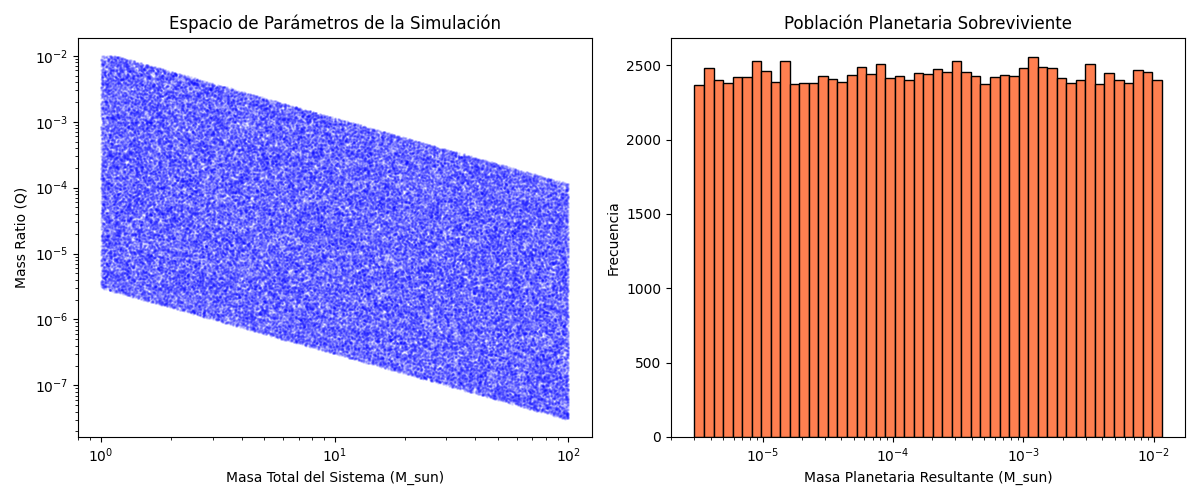

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

# 1. Definir los límites de tu simulación
q_min, q_max = 1e-8, 1e-2         # Rango del Mass Ratio
mtot_min, mtot_max = 1.0, 100.0   # Rango de la Masa Total (M_sun)

# Límites físicos para el filtrado
mp_min = (1 * u.M_earth).to(u.M_sun).value
mp_max = (12 * u.M_jup).to(u.M_sun).value

# Generamos un exceso de muestras (ej. 200,000) porque algunas serán rechazadas
n_inicial = 200000

# 2. Muestreo Log-Uniforme INDEPENDIENTE de las variables del modelo
Q = np.exp(np.random.uniform(np.log(q_min), np.log(q_max), n_inicial))
M_tot = np.exp(np.random.uniform(np.log(mtot_min), np.log(mtot_max), n_inicial))

# 3. Calcular masas individuales para validación
# Sabemos que M_tot = M_s + M_p  y  Q = M_p / M_s
# Despejando:
M_s = M_tot / (1 + Q)
M_p = M_tot * (Q / (1 + Q))

# 4. Muestreo de Rechazo: Crear una "máscara" booleana con sistemas válidos
mascara_valida = (M_p >= mp_min) & (M_p <= mp_max)

# Filtrar los arrays para quedarnos solo con los sistemas físicos
Q_final = Q[mascara_valida]
M_tot_final = M_tot[mascara_valida]
M_p_final = M_p[mascara_valida]
M_s_final = M_s[mascara_valida]

print(f"Sistemas generados inicialmente: {n_inicial}")
print(f"Sistemas físicamente válidos retenidos: {len(Q_final)}")

# --- Visualización del Espacio de Parámetros de tu Modelo ---
plt.figure(figsize=(12, 5))

# Gráfico 1: El espacio de parámetros (M_tot vs Q)
plt.subplot(1, 2, 1)
plt.scatter(M_tot_final, Q_final, s=1, alpha=0.1, color='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Masa Total del Sistema (M_sun)')
plt.ylabel('Mass Ratio (Q)')
plt.title('Espacio de Parámetros de la Simulación')

# Gráfico 2: Distribución de las Masas Planetarias resultantes
plt.subplot(1, 2, 2)
plt.hist(M_p_final, bins=np.logspace(np.log10(mp_min), np.log10(mp_max), 50), color='coral', edgecolor='black')
plt.xscale('log')
plt.xlabel('Masa Planetaria Resultante (M_sun)')
plt.ylabel('Frecuencia')
plt.title('Población Planetaria Sobreviviente')

plt.tight_layout()
plt.show()

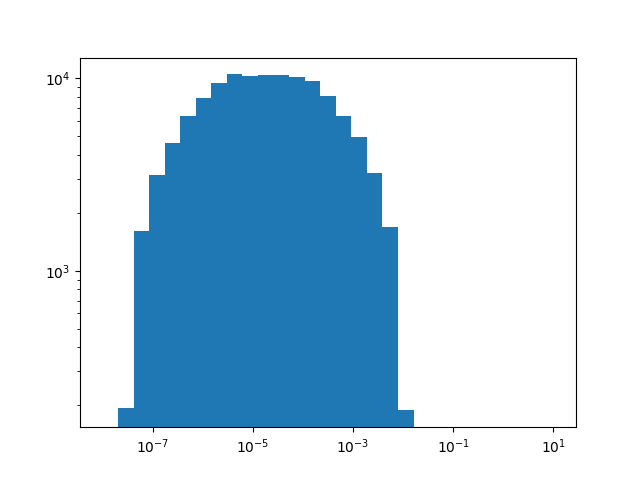

In [61]:
plt.close("all")
plt.hist(Q_final,np.logspace(-8,1,30))
plt.xscale("log")
plt.yscale("log")
plt.show()

Rangos usados:
Mp_min = 3.003e-06 M_sun
Mp_max = 1.146e-02 M_sun
q_min  = 3.003e-08
q_max  = 1.146e-02
s_min  = 1.000e-01
s_max  = 5.000e+00

Sistemas generados: 28800
Sistemas esperados: 28800

Chequeo de masas planetarias:
Mp mínimo generado = 3.004e-06 M_sun
Mp máximo generado = 1.146e-02 M_sun
Mp_min permitido   = 3.003e-06 M_sun
Mp_max permitido   = 1.146e-02 M_sun

Chequeo de masa primaria:
Mstar mínimo generado = 1.000e+00 M_sun
Mstar máximo generado = 1.000e+02 M_sun

Chequeo de q:
q mínimo generado = 3.005e-08
q máximo generado = 1.145e-02

Chequeo de s:
s mínimo generado = 1.000e-01
s máximo generado = 5.000e+00

Uniformidad por celdas en q-s:
Conteo medio por celda = 200.00
Desvío estándar        = 0.00
Mínimo por celda       = 200
Máximo por celda       = 200
Coef. variación        = 0.000e+00


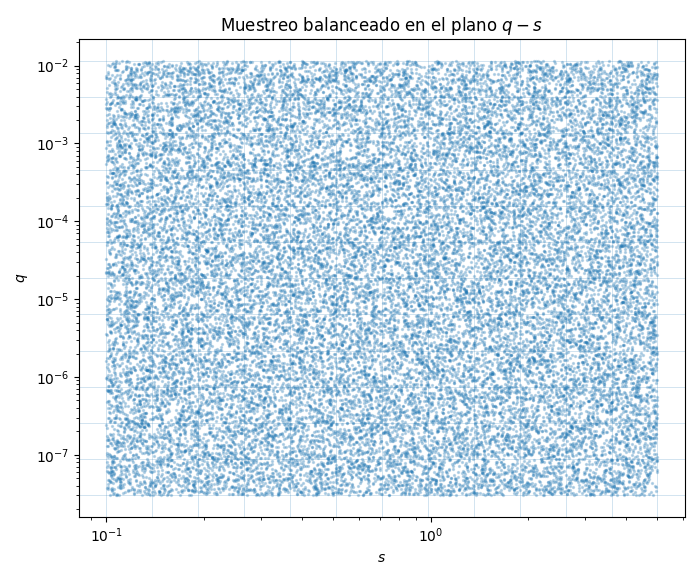

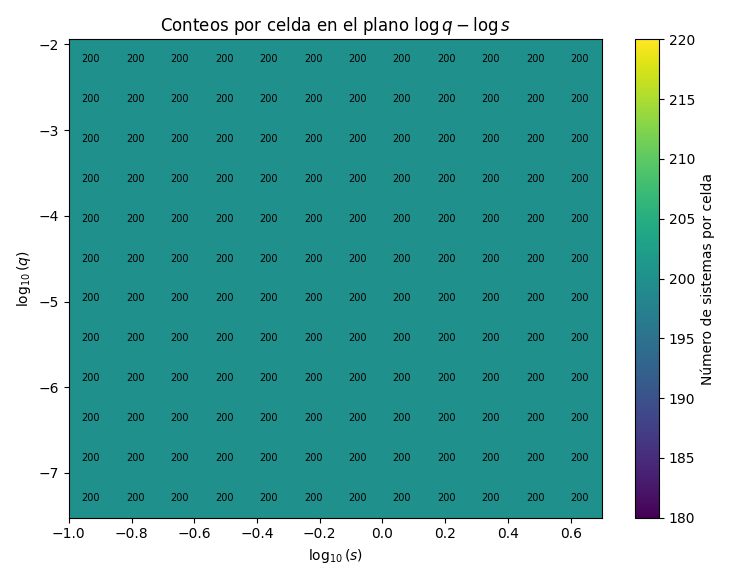

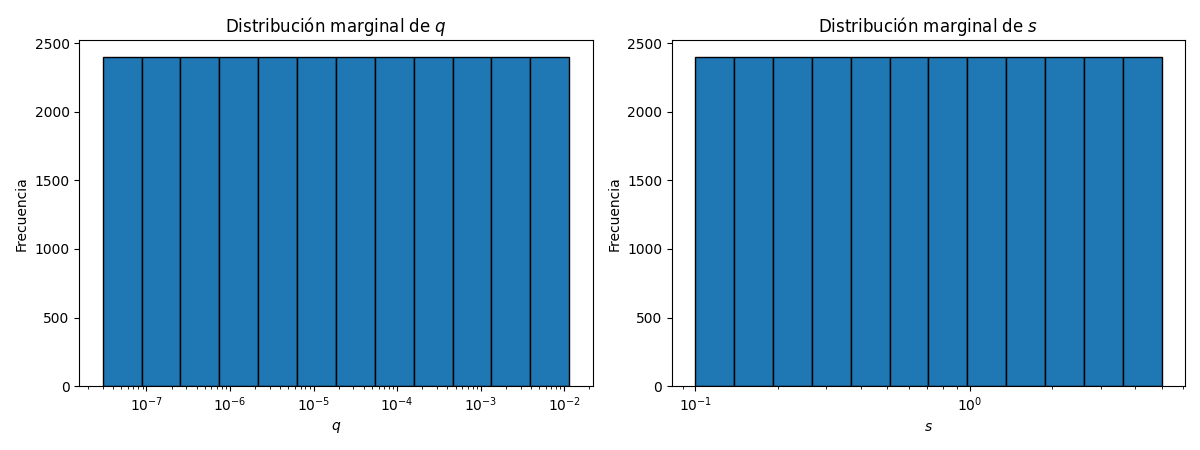

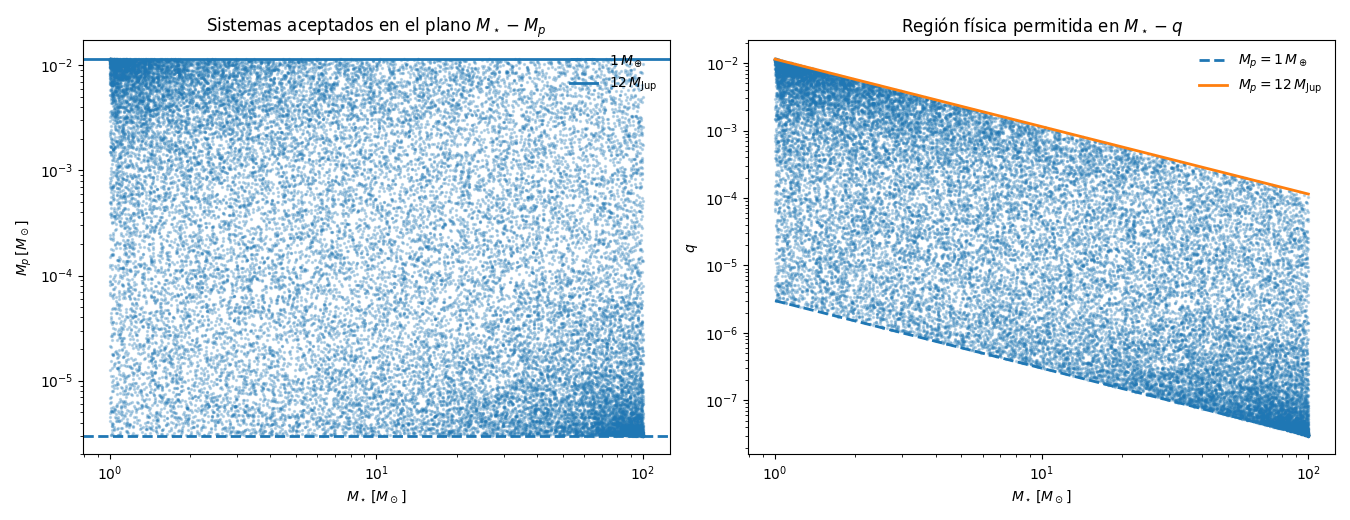

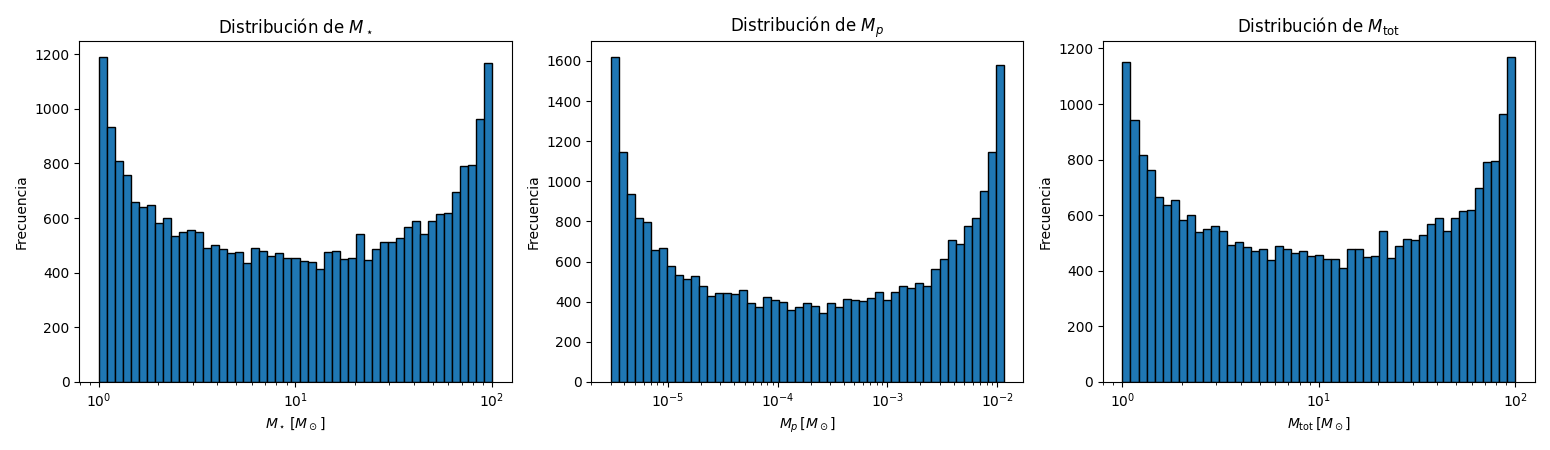

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u


# ============================================================
# 1. Configuración general
# ============================================================

rng = np.random.default_rng(42)

# Rango de masa primaria en M_sun
Mstar_min = 1.0
Mstar_max = 100.0

# Rango planetario
Mp_min = (1.0 * u.M_earth).to(u.M_sun).value
Mp_max = (12.0 * u.M_jup).to(u.M_sun).value

# Rango físico aproximado de q = Mp / Mstar
q_min = Mp_min / Mstar_max
q_max = Mp_max / Mstar_min

# Rango de separación normalizada
s_min = 0.1
s_max = 5.0

# Diseño del muestreo
n_q_bins = 12
n_s_bins = 12
n_per_cell = 200

print("Rangos usados:")
print(f"Mp_min = {Mp_min:.3e} M_sun")
print(f"Mp_max = {Mp_max:.3e} M_sun")
print(f"q_min  = {q_min:.3e}")
print(f"q_max  = {q_max:.3e}")
print(f"s_min  = {s_min:.3e}")
print(f"s_max  = {s_max:.3e}")


# ============================================================
# 2. Funciones auxiliares
# ============================================================

def loguniform(a, b, size=None):
    """
    Muestreo log-uniforme entre a y b.
    """
    return np.exp(rng.uniform(np.log(a), np.log(b), size))


def sample_planetary_system_given_q(q):
    """
    Dado q = Mp / Mstar, elegimos una masa primaria compatible
    con la condición planetaria:
    
        Mp_min <= Mp <= Mp_max
        
    donde
    
        Mp = q Mstar.
        
    Además imponemos:
    
        Mstar_min <= Mstar <= Mstar_max.
    """

    Mstar_low = max(Mstar_min, Mp_min / q)
    Mstar_high = min(Mstar_max, Mp_max / q)

    if Mstar_low >= Mstar_high:
        return None

    Mstar = loguniform(Mstar_low, Mstar_high)
    Mp = q * Mstar
    Mtot = Mstar + Mp

    return Mstar, Mp, Mtot


# ============================================================
# 3. Generación balanceada en el plano q-s
# ============================================================

q_edges = np.logspace(np.log10(q_min), np.log10(q_max), n_q_bins + 1)
s_edges = np.logspace(np.log10(s_min), np.log10(s_max), n_s_bins + 1)

rows = []

for i in range(n_q_bins):
    for j in range(n_s_bins):

        q_lo, q_hi = q_edges[i], q_edges[i + 1]
        s_lo, s_hi = s_edges[j], s_edges[j + 1]

        n_added = 0
        n_try = 0
        max_tries = 200000

        while n_added < n_per_cell and n_try < max_tries:

            n_try += 1

            q = loguniform(q_lo, q_hi)
            s = loguniform(s_lo, s_hi)

            out = sample_planetary_system_given_q(q)

            if out is None:
                continue

            Mstar, Mp, Mtot = out

            rows.append({
                "q": q,
                "s": s,
                "Mstar": Mstar,
                "Mp": Mp,
                "Mtot": Mtot,
                "q_bin": i,
                "s_bin": j,
            })

            n_added += 1

        if n_added < n_per_cell:
            print(
                f"Advertencia: celda q_bin={i}, s_bin={j} "
                f"solo generó {n_added}/{n_per_cell} sistemas."
            )

df = pd.DataFrame(rows)

print()
print(f"Sistemas generados: {len(df)}")
print(f"Sistemas esperados: {n_q_bins * n_s_bins * n_per_cell}")


# ============================================================
# 4. Verificaciones físicas básicas
# ============================================================

print()
print("Chequeo de masas planetarias:")
print(f"Mp mínimo generado = {df['Mp'].min():.3e} M_sun")
print(f"Mp máximo generado = {df['Mp'].max():.3e} M_sun")
print(f"Mp_min permitido   = {Mp_min:.3e} M_sun")
print(f"Mp_max permitido   = {Mp_max:.3e} M_sun")

print()
print("Chequeo de masa primaria:")
print(f"Mstar mínimo generado = {df['Mstar'].min():.3e} M_sun")
print(f"Mstar máximo generado = {df['Mstar'].max():.3e} M_sun")

print()
print("Chequeo de q:")
print(f"q mínimo generado = {df['q'].min():.3e}")
print(f"q máximo generado = {df['q'].max():.3e}")

print()
print("Chequeo de s:")
print(f"s mínimo generado = {df['s'].min():.3e}")
print(f"s máximo generado = {df['s'].max():.3e}")


# ============================================================
# 5. Conteo por celdas en el plano q-s
# ============================================================

counts, q_edges_check, s_edges_check = np.histogram2d(
    df["q"],
    df["s"],
    bins=[q_edges, s_edges]
)

mean_count = counts.mean()
std_count = counts.std()
min_count = counts.min()
max_count = counts.max()

print()
print("Uniformidad por celdas en q-s:")
print(f"Conteo medio por celda = {mean_count:.2f}")
print(f"Desvío estándar        = {std_count:.2f}")
print(f"Mínimo por celda       = {min_count:.0f}")
print(f"Máximo por celda       = {max_count:.0f}")
print(f"Coef. variación        = {std_count / mean_count:.3e}")


# ============================================================
# 6. Figura 1: scatter del plano q-s
# ============================================================

fig, ax = plt.subplots(figsize=(7.0, 5.8))

ax.scatter(df["s"], df["q"], s=2, alpha=0.25)

for qe in q_edges:
    ax.axhline(qe, lw=0.4, alpha=0.35)

for se in s_edges:
    ax.axvline(se, lw=0.4, alpha=0.35)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$q$")
ax.set_title(r"Muestreo balanceado en el plano $q-s$")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Figura 2: mapa de conteos por celda
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 5.8))

im = ax.imshow(
    counts,
    origin="lower",
    aspect="auto",
    extent=[
        np.log10(s_edges[0]),
        np.log10(s_edges[-1]),
        np.log10(q_edges[0]),
        np.log10(q_edges[-1])
    ]
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Número de sistemas por celda")

ax.set_xlabel(r"$\log_{10}(s)$")
ax.set_ylabel(r"$\log_{10}(q)$")
ax.set_title(r"Conteos por celda en el plano $\log q-\log s$")

# Escribir conteos dentro de cada celda
for i in range(n_q_bins):
    for j in range(n_s_bins):
        x_center = 0.5 * (np.log10(s_edges[j]) + np.log10(s_edges[j + 1]))
        y_center = 0.5 * (np.log10(q_edges[i]) + np.log10(q_edges[i + 1]))

        ax.text(
            x_center,
            y_center,
            f"{int(counts[i, j])}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.show()


# ============================================================
# 8. Figura 3: histogramas marginales de q y s
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(12.0, 4.5))

axs[0].hist(
    df["q"],
    bins=q_edges,
    edgecolor="black"
)
axs[0].set_xscale("log")
axs[0].set_xlabel(r"$q$")
axs[0].set_ylabel("Frecuencia")
axs[0].set_title(r"Distribución marginal de $q$")

axs[1].hist(
    df["s"],
    bins=s_edges,
    edgecolor="black"
)
axs[1].set_xscale("log")
axs[1].set_xlabel(r"$s$")
axs[1].set_ylabel("Frecuencia")
axs[1].set_title(r"Distribución marginal de $s$")

plt.tight_layout()
plt.show()


# ============================================================
# 9. Figura 4: verificación física en masas
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(13.5, 5.2))

# ----------------------------
# Mstar vs Mp
# ----------------------------

axs[0].scatter(df["Mstar"], df["Mp"], s=2, alpha=0.25)

axs[0].axhline(Mp_min, ls="--", lw=2, label=r"$1\,M_\oplus$")
axs[0].axhline(Mp_max, ls="-", lw=2, label=r"$12\,M_{\rm Jup}$")

axs[0].set_xscale("log")
axs[0].set_yscale("log")

axs[0].set_xlabel(r"$M_\star\,[M_\odot]$")
axs[0].set_ylabel(r"$M_p\,[M_\odot]$")
axs[0].set_title(r"Sistemas aceptados en el plano $M_\star-M_p$")
axs[0].legend(frameon=False)


# ----------------------------
# Mstar vs q con bandas físicas
# ----------------------------

Mstar_grid = np.logspace(np.log10(Mstar_min), np.log10(Mstar_max), 500)

q_lower = Mp_min / Mstar_grid
q_upper = Mp_max / Mstar_grid

axs[1].scatter(df["Mstar"], df["q"], s=2, alpha=0.25)

axs[1].plot(
    Mstar_grid,
    q_lower,
    ls="--",
    lw=2,
    label=r"$M_p=1\,M_\oplus$"
)

axs[1].plot(
    Mstar_grid,
    q_upper,
    ls="-",
    lw=2,
    label=r"$M_p=12\,M_{\rm Jup}$"
)

axs[1].set_xscale("log")
axs[1].set_yscale("log")

axs[1].set_xlabel(r"$M_\star\,[M_\odot]$")
axs[1].set_ylabel(r"$q$")
axs[1].set_title(r"Región física permitida en $M_\star-q$")
axs[1].legend(frameon=False)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Figura 5: distribución de masas resultantes
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(15.5, 4.5))

axs[0].hist(
    df["Mstar"],
    bins=np.logspace(np.log10(Mstar_min), np.log10(Mstar_max), 50),
    edgecolor="black"
)
axs[0].set_xscale("log")
axs[0].set_xlabel(r"$M_\star\,[M_\odot]$")
axs[0].set_ylabel("Frecuencia")
axs[0].set_title(r"Distribución de $M_\star$")

axs[1].hist(
    df["Mp"],
    bins=np.logspace(np.log10(Mp_min), np.log10(Mp_max), 50),
    edgecolor="black"
)
axs[1].set_xscale("log")
axs[1].set_xlabel(r"$M_p\,[M_\odot]$")
axs[1].set_ylabel("Frecuencia")
axs[1].set_title(r"Distribución de $M_p$")

axs[2].hist(
    df["Mtot"],
    bins=np.logspace(np.log10(df["Mtot"].min()), np.log10(df["Mtot"].max()), 50),
    edgecolor="black"
)
axs[2].set_xscale("log")
axs[2].set_xlabel(r"$M_{\rm tot}\,[M_\odot]$")
axs[2].set_ylabel("Frecuencia")
axs[2].set_title(r"Distribución de $M_{\rm tot}$")

plt.tight_layout()
plt.show()


# ============================================================
# 11. Guardar tabla si querés usarla como input de simulación
# ============================================================

# df.to_csv("planetary_qs_balanced_sample.csv", index=False)

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u


# ============================================================
# 1. Configuración
# ============================================================

rng = np.random.default_rng(42)

# Constante de microlensing
kappa_mas = 8.144  # mas / M_sun

# Límites de masa
Mstar_min = 1.0
Mstar_max = 100.0

Mp_min = (1.0 * u.M_earth).to(u.M_sun).value
Mp_max = (12.0 * u.M_jup).to(u.M_sun).value

# Separación física proyectada
aperp_min_AU = 1.0
aperp_max_AU = 20.0

# Rango físico global de q
q_min = Mp_min / Mstar_max
q_max = Mp_max / Mstar_min

# Rango de s que querés explorar
s_min = 0.05
s_max = 10.0

# Diseño del plano q-s
n_q_bins = 20
n_s_bins = 20
n_per_cell = 50

# Columnas de tu tabla GenuLens
DL_col = "DL_kpc"
DS_col = "DS_kpc"
mu_col = "mu_rel_masyr"


# ============================================================
# 2. Funciones auxiliares
# ============================================================

def log_edges_and_centers(xmin, xmax, n_bins):
    edges = np.logspace(np.log10(xmin), np.log10(xmax), n_bins + 1)
    centers = np.sqrt(edges[:-1] * edges[1:])
    return edges, centers


def allowed_Mtot_interval(q, s, DL_kpc, DS_kpc):
    """
    Devuelve el intervalo permitido de Mtot para un sistema dado.

    q = Mp / Mstar

    Condiciones:
        Mp_min <= Mp <= Mp_max
        Mstar_min <= Mstar <= Mstar_max
        aperp_min <= s R_E <= aperp_max

    Si no existe solución física, devuelve None.
    """

    pi_rel_mas = (1.0 / DL_kpc) - (1.0 / DS_kpc)

    if pi_rel_mas <= 0:
        return None

    # --------------------------------------------------------
    # Condición planetaria:
    # Mp = Mtot q / (1 + q)
    # --------------------------------------------------------

    Mtot_p_lo = Mp_min * (1.0 + q) / q
    Mtot_p_hi = Mp_max * (1.0 + q) / q

    # --------------------------------------------------------
    # Condición estelar:
    # Mstar = Mtot / (1 + q)
    # --------------------------------------------------------

    Mtot_star_lo = Mstar_min * (1.0 + q)
    Mtot_star_hi = Mstar_max * (1.0 + q)

    # --------------------------------------------------------
    # Condición orbital proyectada:
    # aperp = s DL theta_E
    # theta_E = sqrt(kappa Mtot pi_rel)
    # --------------------------------------------------------

    Mtot_orb_lo = (aperp_min_AU / (s * DL_kpc))**2 / (kappa_mas * pi_rel_mas)
    Mtot_orb_hi = (aperp_max_AU / (s * DL_kpc))**2 / (kappa_mas * pi_rel_mas)

    # --------------------------------------------------------
    # Intersección de intervalos
    # --------------------------------------------------------

    Mlo = max(Mtot_p_lo, Mtot_star_lo, Mtot_orb_lo)
    Mhi = min(Mtot_p_hi, Mtot_star_hi, Mtot_orb_hi)

    if Mlo >= Mhi:
        return None

    return Mlo, Mhi, pi_rel_mas


def build_system_from_genulens_row(row, q, s, mode="logmid"):
    """
    Construye un sistema físico a partir de una fila de GenuLens
    y un par q,s.

    mode:
        "logmid" : usa el punto medio logarítmico de Mtot permitido.
        "low"    : usa el límite inferior.
        "high"   : usa el límite superior.
        "random" : muestrea log-uniforme dentro del intervalo permitido.
    """

    DL_kpc = row[DL_col]
    DS_kpc = row[DS_col]
    mu_rel_masyr = row[mu_col]

    interval = allowed_Mtot_interval(q, s, DL_kpc, DS_kpc)

    if interval is None:
        return None

    Mlo, Mhi, pi_rel_mas = interval

    if mode == "logmid":
        Mtot = np.sqrt(Mlo * Mhi)
    elif mode == "low":
        Mtot = Mlo
    elif mode == "high":
        Mtot = Mhi
    elif mode == "random":
        Mtot = np.exp(rng.uniform(np.log(Mlo), np.log(Mhi)))
    else:
        raise ValueError("mode debe ser 'logmid', 'low', 'high' o 'random'.")

    Mstar = Mtot / (1.0 + q)
    Mp = Mtot * q / (1.0 + q)

    theta_E_mas = np.sqrt(kappa_mas * Mtot * pi_rel_mas)

    RE_AU = DL_kpc * theta_E_mas

    aperp_AU = s * RE_AU

    tE_days = 365.25 * theta_E_mas / mu_rel_masyr

    pi_E = pi_rel_mas / theta_E_mas

    return {
        "q": q,
        "s": s,
        "DL_kpc": DL_kpc,
        "DS_kpc": DS_kpc,
        "mu_rel_masyr": mu_rel_masyr,
        "pi_rel_mas": pi_rel_mas,
        "Mtot": Mtot,
        "Mstar": Mstar,
        "Mp": Mp,
        "theta_E_mas": theta_E_mas,
        "RE_AU": RE_AU,
        "aperp_AU": aperp_AU,
        "tE_days": tE_days,
        "pi_E": pi_E,
        "Mtot_allowed_min": Mlo,
        "Mtot_allowed_max": Mhi,
    }

In [70]:
# ============================================================
# 3. Supongamos que ya tenés tu tabla de GenuLens
# ============================================================
# genulens_df = pd.read_csv("/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv")
genulens_df = pd.read_csv(
    "/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv"
)

# Convertir D_L de pc a kpc
genulens_df["DL_kpc"] = genulens_df["D_L"] / 1000.0
genulens_df["DS_kpc"] = genulens_df["D_S"] / 1000.0
genulens_df["mu_rel_masyr"] = genulens_df["mu_rel"] 
# Ejemplo:
# genulens_df = pd.read_csv("genulens_catalog.csv")

# La tabla debe tener, al menos:
#   DL_kpc
#   DS_kpc
#   mu_rel_masyr


# ============================================================
# 4. Grilla q-s
# ============================================================

q_edges, q_centers = log_edges_and_centers(q_min, q_max, n_q_bins)
s_edges, s_centers = log_edges_and_centers(s_min, s_max, n_s_bins)


# ============================================================
# 5. Generación balanceada por celda q-s
# ============================================================

rows = []
cell_rows = []

for i, q in enumerate(q_centers):
    for j, s in enumerate(s_centers):

        valid_indices = []

        # Primero buscamos qué filas de GenuLens son compatibles
        # con esta celda q-s.
        for idx, row in genulens_df.iterrows():
            interval = allowed_Mtot_interval(
                q=q,
                s=s,
                DL_kpc=row[DL_col],
                DS_kpc=row[DS_col],
            )

            if interval is not None:
                valid_indices.append(idx)

        n_valid = len(valid_indices)

        if n_valid == 0:
            cell_rows.append({
                "q_bin": i,
                "s_bin": j,
                "q": q,
                "s": s,
                "n_valid_genulens": 0,
                "n_generated": 0,
            })
            continue

        # Para mantener uniformidad en q-s, generamos n_per_cell
        # sistemas por celda. Si hay menos geometrías compatibles
        # que n_per_cell, muestreamos con reemplazo.
        replace = n_valid < n_per_cell

        chosen_indices = rng.choice(
            valid_indices,
            size=n_per_cell,
            replace=replace
        )

        n_generated = 0

        for idx in chosen_indices:
            row = genulens_df.loc[idx]

            system = build_system_from_genulens_row(
                row=row,
                q=q,
                s=s,
                mode="logmid"
            )

            if system is None:
                continue

            system["genulens_index"] = idx
            system["q_bin"] = i
            system["s_bin"] = j

            rows.append(system)
            n_generated += 1

        cell_rows.append({
            "q_bin": i,
            "s_bin": j,
            "q": q,
            "s": s,
            "n_valid_genulens": n_valid,
            "n_generated": n_generated,
        })

df_planets = pd.DataFrame(rows)
df_cells = pd.DataFrame(cell_rows)

print("Sistemas planetarios generados:")
print(len(df_planets))

print()
print("Celdas sin geometrías compatibles:")b
print(df_cells[df_cells["n_generated"] == 0])

Sistemas planetarios generados:
19250

Celdas sin geometrías compatibles:
     q_bin  s_bin         q         s  n_valid_genulens  n_generated
300     15      0  0.000636  0.057082                 0            0
320     16      0  0.001209  0.057082                 0            0
321     16      1  0.001209  0.074396                 0            0
340     17      0  0.002298  0.057082                 0            0
341     17      1  0.002298  0.074396                 0            0
342     17      2  0.002298  0.096961                 0            0
360     18      0  0.004369  0.057082                 0            0
361     18      1  0.004369  0.074396                 0            0
362     18      2  0.004369  0.096961                 0            0
363     18      3  0.004369  0.126372                 0            0
380     19      0  0.008307  0.057082                 0            0
381     19      1  0.008307  0.074396                 0            0
382     19      2  0.008307  

Columnas disponibles en GenuLens:
['wtj', 'M_L', 'D_L', 'D_S', 'tE', 'thetaE', 'piE', 'piEN', 'piEE', 'mu_rel', 'muSl', 'muSb', 'i_L', 'iS', 'iL', 'fREM']

Usando columna D_S para D_S, convertida de pc a kpc.

Usando columna mu_rel para mu_rel_masyr.

Resumen de geometrías limpias:
             DL_kpc        DS_kpc  mu_rel_masyr
count  10000.000000  10000.000000  10000.000000
mean       5.650576      7.406106      6.920016
std        1.955710      0.926543      4.783892
min        0.039000      0.220000      0.397809
25%        4.113500      7.372000      4.516775
50%        6.371500      7.712000      6.409973
75%        7.318000      7.879000      8.598596
max        7.972000      7.999000    189.160800

Rangos usados:
q_min = 3.0035e-08
q_max = 1.1455e-02
s_min = 5.0000e-02
s_max = 1.0000e+01
Mp_min = 3.0035e-06 M_sun
Mp_max = 1.1455e-02 M_sun

Resultado
Sistemas generados: 19250
Celdas totales: 400
Celdas pobladas: 385
Celdas vacías: 15

Celdas sin geometrías compatibles:
     q_bi

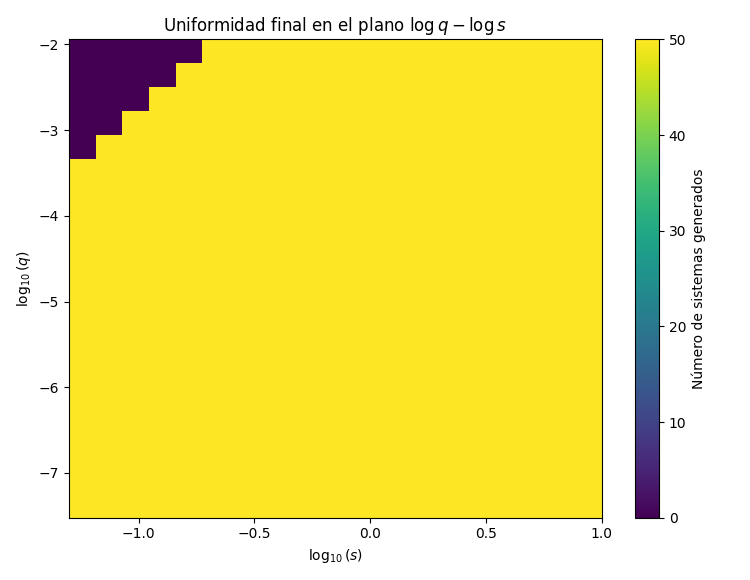

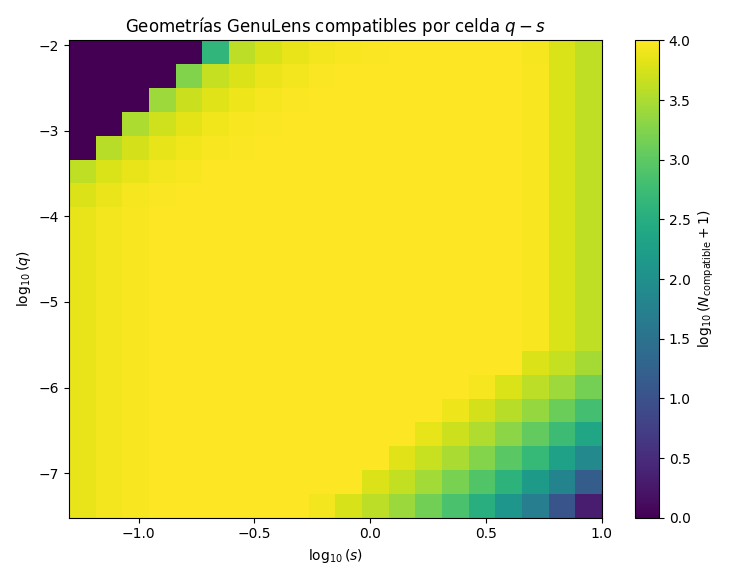

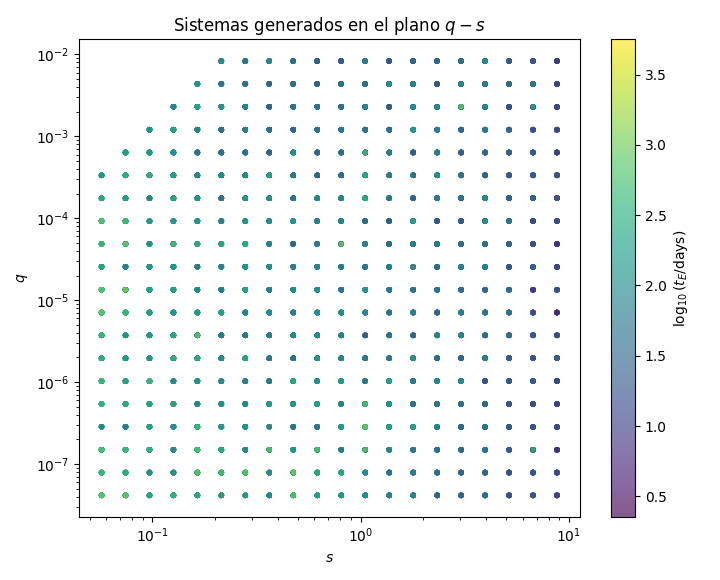

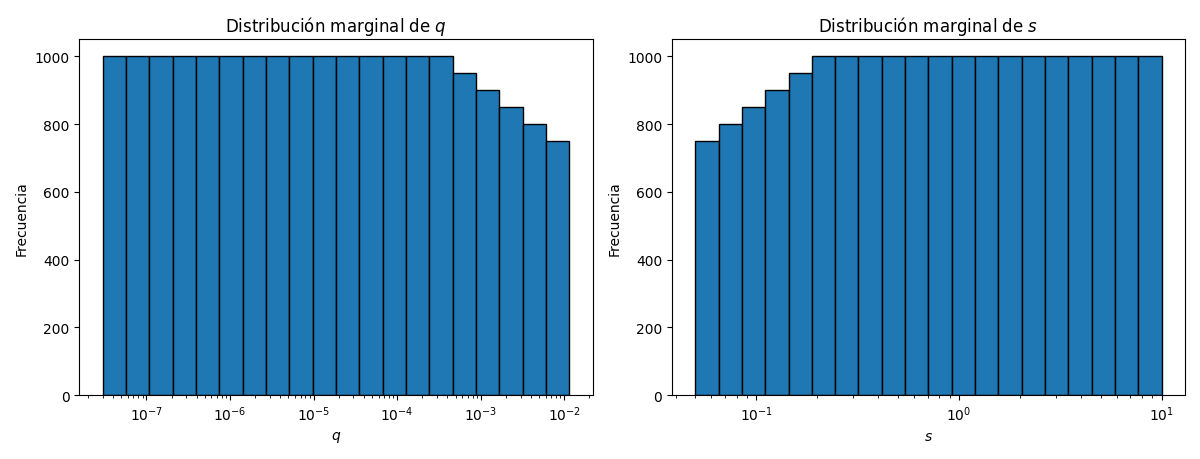

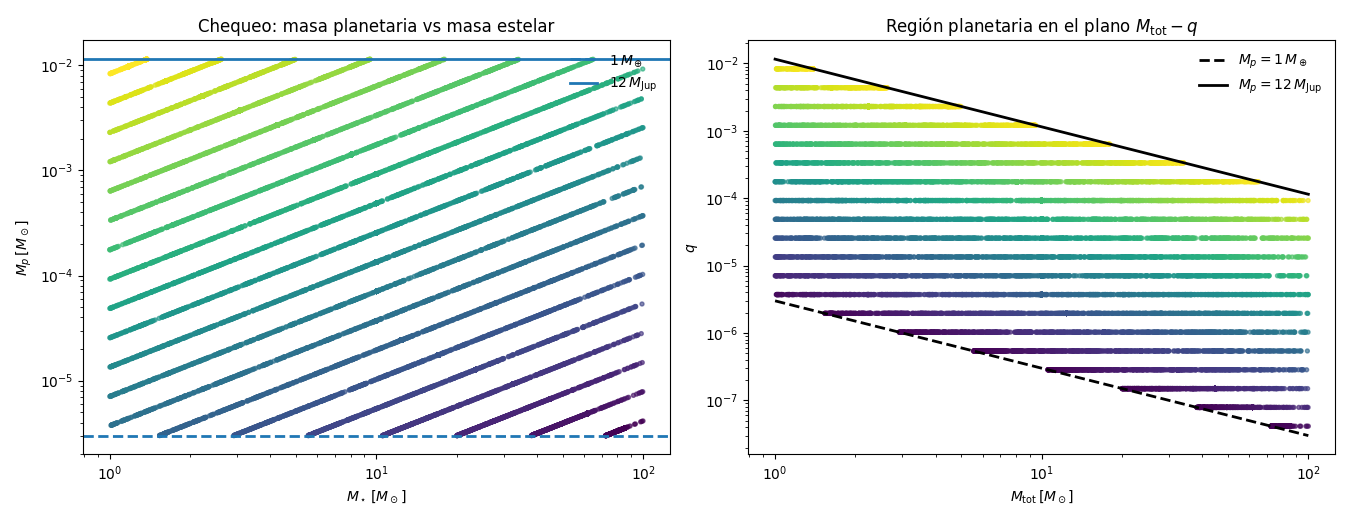

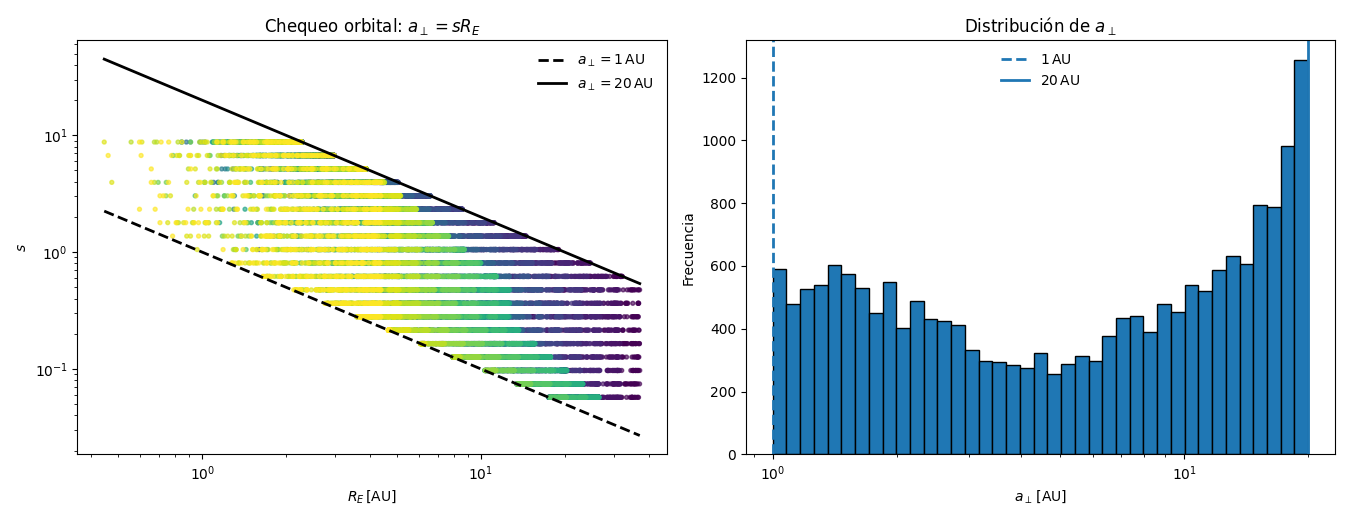

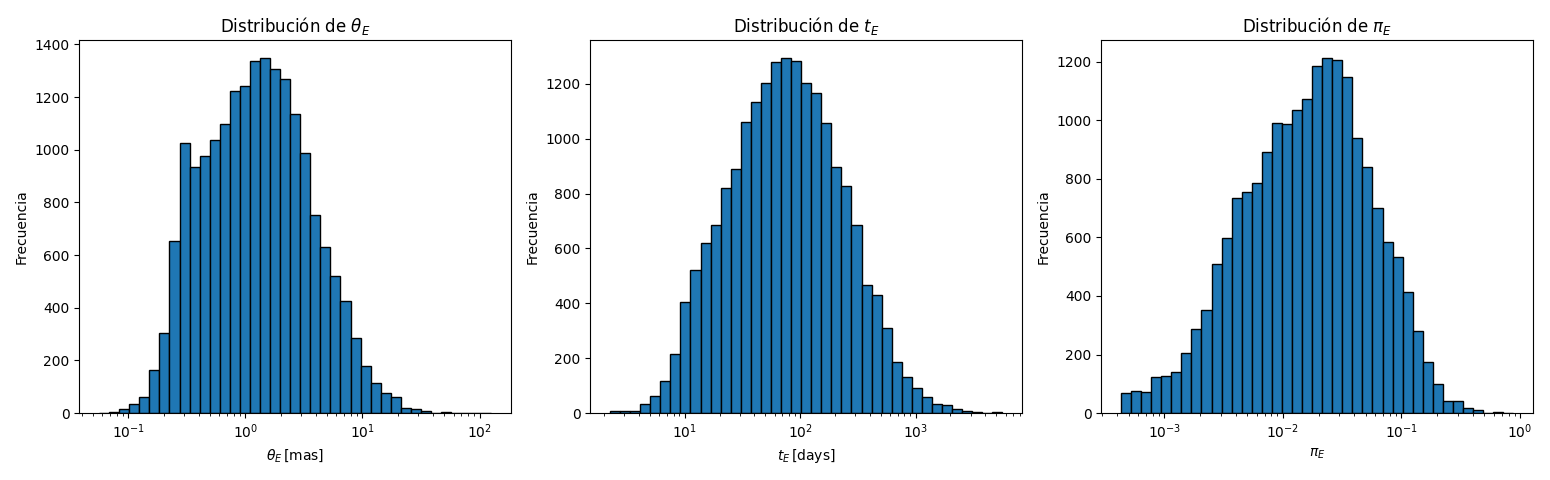

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u


# ============================================================
# 0. Configuración general
# ============================================================

rng = np.random.default_rng(42)

GENULENS_PATH = "/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv"

# -----------------------------
# Columnas GenuLens
# -----------------------------

DL_RAW_COL = "D_L"     # en pc
DS_RAW_COL = "D_S"     # en pc. Si no existe, se usa DS_FIXED_KPC.
MU_REL_COL = None      # si sabés el nombre exacto, ponelo acá. Ej: "mu_rel"

DS_FIXED_KPC = 8.0     # usado solo si no existe columna D_S

# -----------------------------
# Constantes microlensing
# -----------------------------

kappa_mas = 8.144      # mas / M_sun

# -----------------------------
# Límites de masas
# -----------------------------

Mstar_min = 1.0        # M_sun
Mstar_max = 100.0      # M_sun

Mp_min = (1.0 * u.M_earth).to(u.M_sun).value
Mp_max = (12.0 * u.M_jup).to(u.M_sun).value

# -----------------------------
# Límites orbitales proyectados
# -----------------------------

aperp_min_AU = 1.0
aperp_max_AU = 20.0

# -----------------------------
# Rango físico global de q
# q = Mp / Mstar
# -----------------------------

q_min = Mp_min / Mstar_max
q_max = Mp_max / Mstar_min

# -----------------------------
# Rango de s que querés explorar
# -----------------------------

s_min = 0.05
s_max = 10.0

# -----------------------------
# Diseño del plano q-s
# -----------------------------

n_q_bins = 20
n_s_bins = 20
n_per_cell = 50

# Modo para elegir Mtot dentro del intervalo permitido:
# "logmid"  : punto medio logarítmico
# "random"  : log-uniforme dentro del intervalo
# "low"     : límite inferior
# "high"    : límite superior
MTOT_MODE = "logmid"


# ============================================================
# 1. Funciones auxiliares
# ============================================================

def log_edges_and_centers(xmin, xmax, n_bins):
    edges = np.logspace(np.log10(xmin), np.log10(xmax), n_bins + 1)
    centers = np.sqrt(edges[:-1] * edges[1:])
    return edges, centers


def find_mu_rel_column(df, user_col=None):
    """
    Busca columna de mu_rel en mas/yr.
    Si user_col no es None, usa esa columna.
    """

    if user_col is not None:
        if user_col not in df.columns:
            raise KeyError(f"No existe la columna MU_REL_COL={user_col}")
        return user_col

    candidates = [
        "mu_rel_masyr",
        "mu_rel_mas_yr",
        "mu_rel",
        "mu_rel_tot",
        "mu_rel_total",
        "mu",
        "mu_tot",
        "mu_total",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        "No encontré una columna de movimiento propio relativo.\n"
        "Definí MU_REL_COL manualmente.\n\n"
        f"Columnas disponibles:\n{df.columns.tolist()}"
    )


def prepare_genulens_table(path):
    """
    Lee GenuLens y crea columnas estándar:
        DL_kpc
        DS_kpc
        mu_rel_masyr
    """

    df = pd.read_csv(path)

    print("Columnas disponibles en GenuLens:")
    print(df.columns.tolist())

    if DL_RAW_COL not in df.columns:
        raise KeyError(f"No encontré la columna {DL_RAW_COL}")

    # D_L en pc -> kpc
    df["DL_kpc"] = pd.to_numeric(df[DL_RAW_COL], errors="coerce") / 1000.0

    # D_S en pc -> kpc, o valor fijo
    if DS_RAW_COL in df.columns:
        df["DS_kpc"] = pd.to_numeric(df[DS_RAW_COL], errors="coerce") / 1000.0
        print(f"\nUsando columna {DS_RAW_COL} para D_S, convertida de pc a kpc.")
    else:
        df["DS_kpc"] = DS_FIXED_KPC
        print(f"\nNo encontré {DS_RAW_COL}. Usando DS_kpc fijo = {DS_FIXED_KPC:.2f} kpc.")

    # mu_rel
    mu_col = find_mu_rel_column(df, user_col=MU_REL_COL)
    df["mu_rel_masyr"] = pd.to_numeric(df[mu_col], errors="coerce")

    print(f"\nUsando columna {mu_col} para mu_rel_masyr.")

    # Limpieza
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["DL_kpc", "DS_kpc", "mu_rel_masyr"])

    df = df[
        (df["DL_kpc"] > 0) &
        (df["DS_kpc"] > 0) &
        (df["DL_kpc"] < df["DS_kpc"]) &
        (df["mu_rel_masyr"] > 0)
    ].copy()

    df = df.reset_index(drop=True)

    print("\nResumen de geometrías limpias:")
    print(df[["DL_kpc", "DS_kpc", "mu_rel_masyr"]].describe())

    return df


def allowed_Mtot_interval_vectorized(q, s, DL_kpc, DS_kpc):
    
    """
    Calcula el intervalo permitido de Mtot para un par q,s
    y muchas geometrías DL,DS.

    Condiciones:
        Mp_min <= Mp <= Mp_max
        Mstar_min <= Mstar <= Mstar_max
        aperp_min <= s R_E <= aperp_max

    q = Mp / Mstar
    Mtot = Mstar + Mp
    Mp = Mtot q/(1+q)
    Mstar = Mtot/(1+q)
    """

    DL_kpc = np.asarray(DL_kpc, dtype=float)
    DS_kpc = np.asarray(DS_kpc, dtype=float)

    pi_rel_mas = (1.0 / DL_kpc) - (1.0 / DS_kpc)

    # --------------------------------------------------------
    # Restricción planetaria
    # Mp = Mtot q/(1+q)
    # --------------------------------------------------------

    Mtot_p_lo = Mp_min * (1.0 + q) / q
    Mtot_p_hi = Mp_max * (1.0 + q) / q

    # --------------------------------------------------------
    # Restricción estelar
    # Mstar = Mtot/(1+q)
    # --------------------------------------------------------

    Mtot_star_lo = Mstar_min * (1.0 + q)
    Mtot_star_hi = Mstar_max * (1.0 + q)

    # --------------------------------------------------------
    # Restricción orbital proyectada
    # aperp = s R_E
    # R_E[AU] = DL[kpc] theta_E[mas]
    # theta_E = sqrt(kappa Mtot pi_rel)
    # --------------------------------------------------------

    Mtot_orb_lo = (aperp_min_AU / (s * DL_kpc))**2 / (kappa_mas * pi_rel_mas)
    Mtot_orb_hi = (aperp_max_AU / (s * DL_kpc))**2 / (kappa_mas * pi_rel_mas)

    Mlo = np.maximum.reduce([
        np.full_like(DL_kpc, Mtot_p_lo),
        np.full_like(DL_kpc, Mtot_star_lo),
        Mtot_orb_lo,
    ])

    Mhi = np.minimum.reduce([
        np.full_like(DL_kpc, Mtot_p_hi),
        np.full_like(DL_kpc, Mtot_star_hi),
        Mtot_orb_hi,
    ])

    valid = (
        np.isfinite(Mlo) &
        np.isfinite(Mhi) &
        np.isfinite(pi_rel_mas) &
        (pi_rel_mas > 0) &
        (Mlo < Mhi)
    )

    return Mlo, Mhi, pi_rel_mas, valid


def choose_Mtot(Mlo, Mhi, mode="logmid"):
    """
    Elige Mtot dentro del intervalo permitido.
    """

    Mlo = np.asarray(Mlo, dtype=float)
    Mhi = np.asarray(Mhi, dtype=float)

    if mode == "logmid":
        return np.sqrt(Mlo * Mhi)

    if mode == "random":
        return np.exp(rng.uniform(np.log(Mlo), np.log(Mhi)))

    if mode == "low":
        return Mlo

    if mode == "high":
        return Mhi

    raise ValueError("MTOT_MODE debe ser 'logmid', 'random', 'low' o 'high'.")


def build_systems_for_cell(q, s, genulens_df, n_per_cell):
    """
    Para un punto q,s, busca geometrías GenuLens compatibles
    y genera n_per_cell sistemas.
    """

    DL_arr = genulens_df["DL_kpc"].to_numpy()
    DS_arr = genulens_df["DS_kpc"].to_numpy()
    mu_arr = genulens_df["mu_rel_masyr"].to_numpy()

    Mlo, Mhi, pi_rel_mas, valid = allowed_Mtot_interval_vectorized(
        q=q,
        s=s,
        DL_kpc=DL_arr,
        DS_kpc=DS_arr,
    )

    valid_idx = np.where(valid)[0]
    n_valid = len(valid_idx)

    if n_valid == 0:
        return None, n_valid

    replace = n_valid < n_per_cell

    chosen_idx = rng.choice(
        valid_idx,
        size=n_per_cell,
        replace=replace
    )

    DL = DL_arr[chosen_idx]
    DS = DS_arr[chosen_idx]
    mu_rel = mu_arr[chosen_idx]
    pi_rel = pi_rel_mas[chosen_idx]

    Mlo_sel = Mlo[chosen_idx]
    Mhi_sel = Mhi[chosen_idx]

    Mtot = choose_Mtot(Mlo_sel, Mhi_sel, mode=MTOT_MODE)

    Mstar = Mtot / (1.0 + q)
    Mp = Mtot * q / (1.0 + q)

    theta_E_mas = np.sqrt(kappa_mas * Mtot * pi_rel)
    RE_AU = DL * theta_E_mas

    aperp_AU = s * RE_AU

    tE_days = 365.25 * theta_E_mas / mu_rel
    pi_E = pi_rel / theta_E_mas

    out = pd.DataFrame({
        "q": q,
        "s": s,
        "DL_kpc": DL,
        "DS_kpc": DS,
        "mu_rel_masyr": mu_rel,
        "pi_rel_mas": pi_rel,
        "Mtot": Mtot,
        "Mstar": Mstar,
        "Mp": Mp,
        "theta_E_mas": theta_E_mas,
        "RE_AU": RE_AU,
        "aperp_AU": aperp_AU,
        "tE_days": tE_days,
        "pi_E": pi_E,
        "Mtot_allowed_min": Mlo_sel,
        "Mtot_allowed_max": Mhi_sel,
        "genulens_index": chosen_idx,
    })

    return out, n_valid


# ============================================================
# 2. Leer GenuLens
# ============================================================

genulens_df = prepare_genulens_table(GENULENS_PATH)


# ============================================================
# 3. Construir grilla q-s
# ============================================================

q_edges, q_centers = log_edges_and_centers(q_min, q_max, n_q_bins)
s_edges, s_centers = log_edges_and_centers(s_min, s_max, n_s_bins)

print("\nRangos usados:")
print(f"q_min = {q_min:.4e}")
print(f"q_max = {q_max:.4e}")
print(f"s_min = {s_min:.4e}")
print(f"s_max = {s_max:.4e}")
print(f"Mp_min = {Mp_min:.4e} M_sun")
print(f"Mp_max = {Mp_max:.4e} M_sun")


# ============================================================
# 4. Generación balanceada por celda q-s
# ============================================================

all_rows = []
cell_rows = []

for i, q in enumerate(q_centers):
    for j, s in enumerate(s_centers):

        systems_cell, n_valid = build_systems_for_cell(
            q=q,
            s=s,
            genulens_df=genulens_df,
            n_per_cell=n_per_cell,
        )

        if systems_cell is None:
            cell_rows.append({
                "q_bin": i,
                "s_bin": j,
                "q": q,
                "s": s,
                "n_valid_genulens": n_valid,
                "n_generated": 0,
            })
            continue

        systems_cell["q_bin"] = i
        systems_cell["s_bin"] = j

        all_rows.append(systems_cell)

        cell_rows.append({
            "q_bin": i,
            "s_bin": j,
            "q": q,
            "s": s,
            "n_valid_genulens": n_valid,
            "n_generated": len(systems_cell),
        })

df_planets = pd.concat(all_rows, ignore_index=True) if len(all_rows) > 0 else pd.DataFrame()
df_cells = pd.DataFrame(cell_rows)

print("\n========================================")
print("Resultado")
print("========================================")
print(f"Sistemas generados: {len(df_planets)}")
print(f"Celdas totales: {n_q_bins * n_s_bins}")
print(f"Celdas pobladas: {(df_cells['n_generated'] > 0).sum()}")
print(f"Celdas vacías: {(df_cells['n_generated'] == 0).sum()}")

print("\nCeldas sin geometrías compatibles:")
print(df_cells[df_cells["n_generated"] == 0])


# ============================================================
# 5. Verificaciones físicas
# ============================================================

if len(df_planets) == 0:
    raise RuntimeError("No se generó ningún sistema físico. Revisar rangos o columnas.")

df_planets["check_planet_mass"] = (
    (df_planets["Mp"] >= Mp_min) &
    (df_planets["Mp"] <= Mp_max)
)

df_planets["check_stellar_mass"] = (
    (df_planets["Mstar"] >= Mstar_min) &
    (df_planets["Mstar"] <= Mstar_max)
)

df_planets["check_aperp"] = (
    (df_planets["aperp_AU"] >= aperp_min_AU) &
    (df_planets["aperp_AU"] <= aperp_max_AU)
)

df_planets["check_all"] = (
    df_planets["check_planet_mass"] &
    df_planets["check_stellar_mass"] &
    df_planets["check_aperp"]
)

print("\n========================================")
print("Chequeos físicos")
print("========================================")

print(f"Todos cumplen masa planetaria: {df_planets['check_planet_mass'].all()}")
print(f"Todos cumplen masa estelar   : {df_planets['check_stellar_mass'].all()}")
print(f"Todos cumplen a_perp         : {df_planets['check_aperp'].all()}")
print(f"Todos cumplen todo           : {df_planets['check_all'].all()}")

print("\nRangos generados:")
print(f"Mp       = [{df_planets['Mp'].min():.4e}, {df_planets['Mp'].max():.4e}] M_sun")
print(f"Mstar    = [{df_planets['Mstar'].min():.4e}, {df_planets['Mstar'].max():.4e}] M_sun")
print(f"Mtot     = [{df_planets['Mtot'].min():.4e}, {df_planets['Mtot'].max():.4e}] M_sun")
print(f"a_perp   = [{df_planets['aperp_AU'].min():.4e}, {df_planets['aperp_AU'].max():.4e}] AU")
print(f"theta_E  = [{df_planets['theta_E_mas'].min():.4e}, {df_planets['theta_E_mas'].max():.4e}] mas")
print(f"tE       = [{df_planets['tE_days'].min():.4e}, {df_planets['tE_days'].max():.4e}] days")
print(f"pi_E     = [{df_planets['pi_E'].min():.4e}, {df_planets['pi_E'].max():.4e}]")


# ============================================================
# 6. Verificación de uniformidad en q-s
# ============================================================

counts, _, _ = np.histogram2d(
    df_planets["q"],
    df_planets["s"],
    bins=[q_edges, s_edges]
)

nonzero_counts = counts[counts > 0]

print("\n========================================")
print("Uniformidad en q-s")
print("========================================")
print(f"Conteo esperado por celda poblada = {n_per_cell}")
print(f"Conteo medio en celdas pobladas   = {nonzero_counts.mean():.2f}")
print(f"Desvío en celdas pobladas         = {nonzero_counts.std():.2f}")
print(f"Mínimo en celdas pobladas         = {nonzero_counts.min():.0f}")
print(f"Máximo en celdas pobladas         = {nonzero_counts.max():.0f}")

if nonzero_counts.mean() > 0:
    print(f"Coeficiente de variación          = {nonzero_counts.std() / nonzero_counts.mean():.4e}")


# ============================================================
# 7. Mapas auxiliares por celda
# ============================================================

compat_map = np.zeros((n_q_bins, n_s_bins))
generated_map = np.zeros((n_q_bins, n_s_bins))

for _, row in df_cells.iterrows():
    ii = int(row["q_bin"])
    jj = int(row["s_bin"])
    compat_map[ii, jj] = row["n_valid_genulens"]
    generated_map[ii, jj] = row["n_generated"]


# ============================================================
# 8. Gráficos
# ============================================================

# ------------------------------------------------------------
# Figura 1: mapa de conteos finales q-s
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.5, 5.8))

im = ax.imshow(
    counts,
    origin="lower",
    aspect="auto",
    extent=[
        np.log10(s_edges[0]),
        np.log10(s_edges[-1]),
        np.log10(q_edges[0]),
        np.log10(q_edges[-1]),
    ],
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Número de sistemas generados")

ax.set_xlabel(r"$\log_{10}(s)$")
ax.set_ylabel(r"$\log_{10}(q)$")
ax.set_title(r"Uniformidad final en el plano $\log q-\log s$")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Figura 2: geometrías GenuLens compatibles por celda
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.5, 5.8))

im = ax.imshow(
    np.log10(compat_map + 1),
    origin="lower",
    aspect="auto",
    extent=[
        np.log10(s_edges[0]),
        np.log10(s_edges[-1]),
        np.log10(q_edges[0]),
        np.log10(q_edges[-1]),
    ],
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\log_{10}(N_{\rm compatible}+1)$")

ax.set_xlabel(r"$\log_{10}(s)$")
ax.set_ylabel(r"$\log_{10}(q)$")
ax.set_title(r"Geometrías GenuLens compatibles por celda $q-s$")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Figura 3: scatter q-s coloreado por tE
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.2, 5.8))

sc = ax.scatter(
    df_planets["s"],
    df_planets["q"],
    c=np.log10(df_planets["tE_days"]),
    s=8,
    alpha=0.65,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$q$")
ax.set_title(r"Sistemas generados en el plano $q-s$")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\log_{10}(t_E/{\rm days})$")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Figura 4: histogramas marginales de q y s
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(12.0, 4.6))

axs[0].hist(df_planets["q"], bins=q_edges, edgecolor="black")
axs[0].set_xscale("log")
axs[0].set_xlabel(r"$q$")
axs[0].set_ylabel("Frecuencia")
axs[0].set_title(r"Distribución marginal de $q$")

axs[1].hist(df_planets["s"], bins=s_edges, edgecolor="black")
axs[1].set_xscale("log")
axs[1].set_xlabel(r"$s$")
axs[1].set_ylabel("Frecuencia")
axs[1].set_title(r"Distribución marginal de $s$")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Figura 5: vínculo de masa planetaria y masa estelar
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(13.5, 5.2))

axs[0].scatter(
    df_planets["Mstar"],
    df_planets["Mp"],
    c=np.log10(df_planets["q"]),
    s=8,
    alpha=0.65,
)

axs[0].axhline(Mp_min, ls="--", lw=2, label=r"$1\,M_\oplus$")
axs[0].axhline(Mp_max, ls="-", lw=2, label=r"$12\,M_{\rm Jup}$")

axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_xlabel(r"$M_\star\,[M_\odot]$")
axs[0].set_ylabel(r"$M_p\,[M_\odot]$")
axs[0].set_title(r"Chequeo: masa planetaria vs masa estelar")
axs[0].legend(frameon=False)

Mtot_grid = np.logspace(
    np.log10(df_planets["Mtot"].min()),
    np.log10(df_planets["Mtot"].max()),
    500,
)

q_lower = Mp_min / (Mtot_grid - Mp_min)
q_upper = Mp_max / (Mtot_grid - Mp_max)

axs[1].scatter(
    df_planets["Mtot"],
    df_planets["q"],
    c=np.log10(df_planets["Mp"]),
    s=8,
    alpha=0.65,
)

axs[1].plot(Mtot_grid, q_lower, "k--", lw=2, label=r"$M_p=1\,M_\oplus$")
axs[1].plot(Mtot_grid, q_upper, "k-", lw=2, label=r"$M_p=12\,M_{\rm Jup}$")

axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlabel(r"$M_{\rm tot}\,[M_\odot]$")
axs[1].set_ylabel(r"$q$")
axs[1].set_title(r"Región planetaria en el plano $M_{\rm tot}-q$")
axs[1].legend(frameon=False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Figura 6: vínculo orbital a_perp = s R_E
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(13.5, 5.2))

axs[0].scatter(
    df_planets["RE_AU"],
    df_planets["s"],
    c=np.log10(df_planets["q"]),
    s=8,
    alpha=0.65,
)

RE_grid = np.logspace(
    np.log10(df_planets["RE_AU"].min()),
    np.log10(df_planets["RE_AU"].max()),
    500,
)

axs[0].plot(
    RE_grid,
    aperp_min_AU / RE_grid,
    "k--",
    lw=2,
    label=r"$a_\perp=1\,{\rm AU}$",
)

axs[0].plot(
    RE_grid,
    aperp_max_AU / RE_grid,
    "k-",
    lw=2,
    label=r"$a_\perp=20\,{\rm AU}$",
)

axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_xlabel(r"$R_E\,[{\rm AU}]$")
axs[0].set_ylabel(r"$s$")
axs[0].set_title(r"Chequeo orbital: $a_\perp=sR_E$")
axs[0].legend(frameon=False)

axs[1].hist(
    df_planets["aperp_AU"],
    bins=np.logspace(np.log10(aperp_min_AU), np.log10(aperp_max_AU), 40),
    edgecolor="black",
)

axs[1].axvline(aperp_min_AU, ls="--", lw=2, label=r"$1\,{\rm AU}$")
axs[1].axvline(aperp_max_AU, ls="-", lw=2, label=r"$20\,{\rm AU}$")

axs[1].set_xscale("log")
axs[1].set_xlabel(r"$a_\perp\,[{\rm AU}]$")
axs[1].set_ylabel("Frecuencia")
axs[1].set_title(r"Distribución de $a_\perp$")
axs[1].legend(frameon=False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Figura 7: parámetros derivados
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(15.5, 4.8))

axs[0].hist(
    df_planets["theta_E_mas"],
    bins=np.logspace(
        np.log10(df_planets["theta_E_mas"].min()),
        np.log10(df_planets["theta_E_mas"].max()),
        40,
    ),
    edgecolor="black",
)

axs[0].set_xscale("log")
axs[0].set_xlabel(r"$\theta_E\,[{\rm mas}]$")
axs[0].set_ylabel("Frecuencia")
axs[0].set_title(r"Distribución de $\theta_E$")

axs[1].hist(
    df_planets["tE_days"],
    bins=np.logspace(
        np.log10(df_planets["tE_days"].min()),
        np.log10(df_planets["tE_days"].max()),
        40,
    ),
    edgecolor="black",
)

axs[1].set_xscale("log")
axs[1].set_xlabel(r"$t_E\,[{\rm days}]$")
axs[1].set_ylabel("Frecuencia")
axs[1].set_title(r"Distribución de $t_E$")

axs[2].hist(
    df_planets["pi_E"],
    bins=np.logspace(
        np.log10(df_planets["pi_E"].min()),
        np.log10(df_planets["pi_E"].max()),
        40,
    ),
    edgecolor="black",
)

axs[2].set_xscale("log")
axs[2].set_xlabel(r"$\pi_E$")
axs[2].set_ylabel("Frecuencia")
axs[2].set_title(r"Distribución de $\pi_E$")

plt.tight_layout()
plt.show()


# ============================================================
# 9. Guardar resultados
# ============================================================

# df_planets.to_csv("planetary_qs_uniform_genulens_physical.csv", index=False)
# df_cells.to_csv("planetary_qs_uniform_genulens_cell_report.csv", index=False)